### Overview

Evaluation of word2vec-based machine learning models using TCGA-BRCA test set (fully external test set)

#### Note: Use Scipy Version 1.12 to be able to import Gensim

In [1]:
import pandas as pd
import numpy as np
from gensim.models import Word2Vec
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
import random
import matplotlib.pyplot as plt
import seaborn as sns

#### 1. Import and prepare data

In [2]:
# import tpm counts training set
train_data = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/SCANB_GSE202203/scanb_hiseq_train_test_sets/train_test_80_20/SCANB_HiSeq_pam50gene_tpm_counts_subtype_train_80.csv", 
                          header=0, index_col=0)

In [3]:
# import validation data
val_data = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/TCGA_BRCA/tcga_brca_cleaned_data/pam50genes_tpm_counts_subtype_tcga_brca.csv", 
                       header=0, index_col=0)

In [4]:
# keep only PAM50 gene counts
X_train = train_data.iloc[:, 0:50]
X_test = val_data.iloc[:,0:50]
print(X_train.shape)
print(X_test.shape)
print(X_train.columns.equals(X_test.columns))

(2204, 50)
(1031, 50)
True


In [5]:
# save sample subtype info separately as y_train and y_test
y_train = train_data.iloc[:, [50]]
y_test = val_data.iloc[:,[50]]
print(y_train.shape)
print(y_test.shape)

(2204, 1)
(1031, 1)


In [6]:
# check if the indices of x and y match
print(X_train.index.equals(y_train.index))
print(X_test.index.equals(y_test.index))

True
True


In [7]:
# label encoding
label_encoder = LabelEncoder()
y_train['subtype'] = label_encoder.fit_transform(y_train['subtype'])
y_test['subtype'] = label_encoder.transform(y_test['subtype'])

# check class count before label encoding
print("Class count before label encoding")
print("Train set\n",train_data['subtype'].value_counts())
print("\nTest set\n",val_data['subtype'].value_counts())

# check class count after label encoding
print("\nClass count after label encoding")
print("Train set\n",y_train['subtype'].value_counts())
print("\nTest set\n",y_test['subtype'].value_counts())

Class count before label encoding
Train set
 subtype
LumA     1119
LumB      654
Basal     230
Her2      201
Name: count, dtype: int64

Test set
 subtype
LumA     555
LumB     209
Basal    185
Her2      82
Name: count, dtype: int64

Class count after label encoding
Train set
 subtype
2    1119
3     654
0     230
1     201
Name: count, dtype: int64

Test set
 subtype
2    555
3    209
0    185
1     82
Name: count, dtype: int64


C:\Users\User\AppData\Local\Temp\ipykernel_20504\535389317.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_train['subtype'] = label_encoder.fit_transform(y_train['subtype'])
C:\Users\User\AppData\Local\Temp\ipykernel_20504\535389317.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  y_test['subtype'] = label_encoder.transform(y_test['subtype'])


#### 2. Evaluate word2vec-based classification on the test set

In [8]:
# function to rank gene column names to create gene sentence
def get_top_genes(row):
    return row.sort_values(ascending=False).index.to_list()

In [9]:
# function to get average embedding
# need to average the word embeddings because it creates a fixed-length single vector representation for the entire sequence
# useful for machine learning models which needs a single input vector for each sample
# Word2vec creates (m,n) embedding vector for each sequence (m: number of words in the sequence, n: embedding vector size)
# each word has an embedding of shape (vector size,)
# the average of the embeddings have to be computed column wise to maintain the shape of embedding vector size
# averaging the mean row-wise is incorrect, because it reduces the embedding of an entire word into a single value.
def get_average_vector(sequence, model):
    vectors = [model.wv[word] for word in sequence if word in model.wv]
    # return a zero vector if no valid words
    if len(vectors) == 0:
        return np.zeros(model.vector_size)  
    return np.mean(vectors, axis=0)


In [10]:
# rank the gene names for all the samples in X_train
X_train_ranked_geneList = X_train.apply(lambda row: get_top_genes(row), axis=1)
X_train_ranked_geneList = pd.DataFrame(X_train_ranked_geneList , index=X_train.index, columns=['ranked_gene_list'])

In [11]:
# rank the gene names for all the samples in X_test
X_test_ranked_geneList = X_test.apply(lambda row: get_top_genes(row), axis=1)
X_test_ranked_geneList = pd.DataFrame(X_test_ranked_geneList , index=X_test.index, columns=['ranked_gene_list'])

In [12]:
print(X_train_ranked_geneList.shape)
print(X_test_ranked_geneList.shape)

(2204, 1)
(1031, 1)


In [13]:
seed = 42
np.random.seed(seed)
random.seed(seed)

#### 2.1 For Random Forest

In [14]:
random.seed(seed)
np.random.seed(seed)

# train word2vec (using the optimal parameters)
w2v_model_rf = Word2Vec(X_train_ranked_geneList['ranked_gene_list'], vector_size=800, sg=1, alpha=0.01, window=6, epochs=10,
                         seed=seed, workers=1)

# Convert each sequence of each sample to average word embedding vector and save it as a 2d array
x_train_vect_rf = np.array([get_average_vector(seq, w2v_model_rf) for seq in X_train_ranked_geneList['ranked_gene_list']])
x_test_vect_rf = np.array([get_average_vector(seq, w2v_model_rf) for seq in X_test_ranked_geneList['ranked_gene_list']])

print('Embedding vector sequence in training: ',len(x_train_vect_rf[0]))
print('Embedding vector sequence in validation: ',len(x_test_vect_rf[0]))
print('Embedding vector shape in training: ',x_train_vect_rf.shape)
print('Embedding vector shape in validation: ',x_test_vect_rf.shape)

# standardization of the embedding vectors
scaler = StandardScaler()
x_train_vect_scaled_rf = scaler.fit_transform(x_train_vect_rf)
x_test_vect_scaled_rf = scaler.transform(x_test_vect_rf)

print('Embedding vector shape in training after scaling: ',x_train_vect_scaled_rf.shape)
print('Embedding vector shape in test after scaling: ',x_test_vect_scaled_rf.shape)

# pca transformation
pca_rf = PCA(random_state=seed, n_components=14)
x_train_pca_rf = pca_rf.fit_transform(x_train_vect_scaled_rf)
x_test_pca_rf = pca_rf.transform(x_test_vect_scaled_rf)

print(f'Shape of training and test after PCA: {x_train_pca_rf.shape} and {x_test_pca_rf.shape}')

# build rf classifier
rfc = RandomForestClassifier(n_estimators=100, min_samples_leaf=1, min_samples_split=2, max_depth=None, random_state=seed)

# fit the rf classifier on the training fold sets
rfc.fit(x_train_pca_rf, y_train.values.ravel())

# make predictions on the validation fold set
y_pred_rf = rfc.predict(x_test_pca_rf)

# calculate metric scores
mcc_rf = metrics.matthews_corrcoef(y_test.values.ravel(), y_pred_rf)
f1_rf = metrics.f1_score(y_test.values.ravel(), y_pred_rf, average='macro')
recall_rf = metrics.recall_score(y_test.values.ravel(), y_pred_rf, average='macro')
precision_rf = metrics.precision_score(y_test.values.ravel(), y_pred_rf, average='macro')
accuracy_rf = metrics.accuracy_score(y_test.values.ravel(), y_pred_rf)

print(metrics.classification_report(y_test.values.ravel(), y_pred_rf, digits=4))


Embedding vector sequence in training:  800
Embedding vector sequence in validation:  800
Embedding vector shape in training:  (2204, 800)
Embedding vector shape in validation:  (1031, 800)
Embedding vector shape in training after scaling:  (2204, 800)
Embedding vector shape in test after scaling:  (1031, 800)
Shape of training and test after PCA: (2204, 14) and (1031, 14)
              precision    recall  f1-score   support

           0     0.9840    0.9946    0.9892       185
           1     0.7300    0.8902    0.8022        82
           2     1.0000    0.3964    0.5677       555
           3     0.3740    0.9378    0.5348       209

    accuracy                         0.6528      1031
   macro avg     0.7720    0.8048    0.7235      1031
weighted avg     0.8488    0.6528    0.6553      1031



In [15]:
print('Accuracy: ', round(accuracy_rf,4))
print('Macro Precision: ', round(precision_rf,4))
print('Macro Recall: ', round(recall_rf,4))
print('Macro F1: ', round(f1_rf,4))
print('Macro MCC: ', round(mcc_rf,4))

Accuracy:  0.6528
Macro Precision:  0.772
Macro Recall:  0.8048
Macro F1:  0.7235
Macro MCC:  0.6145


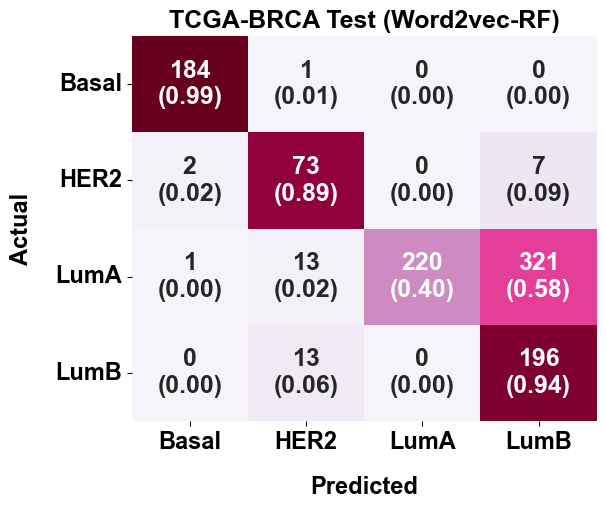

In [16]:
# Compute actual and normalized confusion matrices
cm_actual = metrics.confusion_matrix(y_test.values.ravel(), y_pred_rf, labels=[0,1,2,3])
cm_normalized = metrics.confusion_matrix(y_test.values.ravel(), y_pred_rf, labels=[0,1,2,3], normalize='true')

# Define class labels
new_labels = ['Basal', 'HER2', 'LumA', 'LumB']

# Create formatted annotations combining actual counts and normalized values
annotations = np.array([
    [f"{cm_actual[i, j]}\n({cm_normalized[i, j]:.2f})" for j in range(cm_actual.shape[1])]
    for i in range(cm_actual.shape[0])
])

# Convert normalized confusion matrix to DataFrame for visualization
cm_df = pd.DataFrame(cm_normalized, index=new_labels, columns=new_labels)

# Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=annotations, fmt='', cmap='PuRd', cbar=False, 
            annot_kws={"size": 18, "family": 'Arial', 'weight':'bold'})

# Formatting labels and title
plt.xticks(fontsize=17, fontfamily='Arial', rotation=0, weight='bold')  
plt.yticks(fontsize=17, fontfamily='Arial', rotation=0, weight='bold') 
plt.xlabel('Predicted', fontsize=17, fontfamily='Arial', labelpad=16, weight='bold')
plt.ylabel('Actual', fontsize=17, fontfamily='Arial', labelpad=16, weight='bold')
plt.title('TCGA-BRCA Test (Word2vec-RF)', fontsize=18, fontfamily='Arial', weight='bold')
plt.show()

#### 2.2 SVM

In [17]:
random.seed(seed)
np.random.seed(seed)

# train word2vec (using the optimal parameters)
w2v_model_svm = Word2Vec(X_train_ranked_geneList['ranked_gene_list'], vector_size=600, sg=1, alpha=0.01, window=5, epochs=5,
                         seed=seed, workers=1)

# Convert each sequence of each sample to average word embedding vector and save it as a 2d array
x_train_vect_svm = np.array([get_average_vector(seq, w2v_model_svm) for seq in X_train_ranked_geneList['ranked_gene_list']])
x_test_vect_svm = np.array([get_average_vector(seq, w2v_model_svm) for seq in X_test_ranked_geneList['ranked_gene_list']])

print('Embedding vector sequence in training: ',len(x_train_vect_svm[0]))
print('Embedding vector sequence in validation: ',len(x_test_vect_svm[0]))
print('Embedding vector shape in training: ',x_train_vect_svm.shape)
print('Embedding vector shape in validation: ',x_test_vect_svm.shape)

# standardization of the embedding vectors
scaler = StandardScaler()
x_train_vect_scaled_svm = scaler.fit_transform(x_train_vect_svm)
x_test_vect_scaled_svm = scaler.transform(x_test_vect_svm)

print('Embedding vector shape in training after scaling: ',x_train_vect_scaled_svm.shape)
print('Embedding vector shape in test after scaling: ',x_test_vect_scaled_svm.shape)

# pca transformation
pca_svm = PCA(random_state=seed, n_components=72)
x_train_pca_svm = pca_svm.fit_transform(x_train_vect_scaled_svm)
x_test_pca_svm = pca_svm.transform(x_test_vect_scaled_svm)

print(f'Shape of training and test after PCA: {x_train_pca_svm.shape} and {x_test_pca_svm.shape}')
    
# build svm classifier
svm = SVC(C=1, gamma='scale', kernel='rbf', random_state=seed)

# fit the svm classifier on the training fold sets
svm.fit(x_train_pca_svm, y_train.values.ravel())

# make predictions on the validation fold set
y_pred_svm = svm.predict(x_test_pca_svm)

# calculate metric scores
mcc_svm = metrics.matthews_corrcoef(y_test.values.ravel(), y_pred_svm)
f1_svm = metrics.f1_score(y_test.values.ravel(), y_pred_svm, average='macro')
recall_svm = metrics.recall_score(y_test.values.ravel(), y_pred_svm, average='macro')
precision_svm = metrics.precision_score(y_test.values.ravel(), y_pred_svm, average='macro')
accuracy_svm = metrics.accuracy_score(y_test.values.ravel(), y_pred_svm)

print(metrics.classification_report(y_test.values.ravel(), y_pred_svm, digits=4))


Embedding vector sequence in training:  600
Embedding vector sequence in validation:  600
Embedding vector shape in training:  (2204, 600)
Embedding vector shape in validation:  (1031, 600)
Embedding vector shape in training after scaling:  (2204, 600)
Embedding vector shape in test after scaling:  (1031, 600)
Shape of training and test after PCA: (2204, 72) and (1031, 72)
              precision    recall  f1-score   support

           0     0.9946    0.9892    0.9919       185
           1     0.7822    0.9634    0.8634        82
           2     1.0000    0.4757    0.6447       555
           3     0.4108    0.9474    0.5731       209

    accuracy                         0.7022      1031
   macro avg     0.7969    0.8439    0.7683      1031
weighted avg     0.8623    0.7022    0.7099      1031



In [18]:
print('Accuracy: ', round(accuracy_svm,4))
print('Macro Precision: ', round(precision_svm,4))
print('Macro Recall: ', round(recall_svm,4))
print('Macro F1: ', round(f1_svm,4))
print('Macro MCC: ', round(mcc_svm,4))

Accuracy:  0.7022
Macro Precision:  0.7969
Macro Recall:  0.8439
Macro F1:  0.7683
Macro MCC:  0.6591


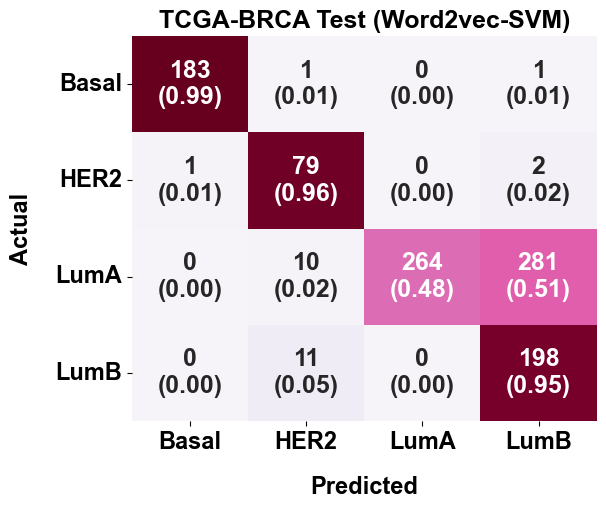

In [19]:
# Compute actual and normalized confusion matrices
cm_actual = metrics.confusion_matrix(y_test.values.ravel(), y_pred_svm, labels=[0,1,2,3])
cm_normalized = metrics.confusion_matrix(y_test.values.ravel(), y_pred_svm, labels=[0,1,2,3], normalize='true')

# Define class labels
new_labels = ['Basal', 'HER2', 'LumA', 'LumB']

# Create formatted annotations combining actual counts and normalized values
annotations = np.array([
    [f"{cm_actual[i, j]}\n({cm_normalized[i, j]:.2f})" for j in range(cm_actual.shape[1])]
    for i in range(cm_actual.shape[0])
])

# Convert normalized confusion matrix to DataFrame for visualization
cm_df = pd.DataFrame(cm_normalized, index=new_labels, columns=new_labels)

# plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=annotations, fmt='', cmap='PuRd', cbar=False, 
            annot_kws={"size": 18, "family": 'Arial', 'weight':'bold'})

# Formatting labels and title
plt.xticks(fontsize=17, fontfamily='Arial', rotation=0, weight='bold')  
plt.yticks(fontsize=17, fontfamily='Arial', rotation=0, weight='bold') 
plt.xlabel('Predicted', fontsize=17, fontfamily='Arial', labelpad=16, weight='bold')
plt.ylabel('Actual', fontsize=17, fontfamily='Arial', labelpad=16, weight='bold')
plt.title('TCGA-BRCA Test (Word2vec-SVM)', fontsize=18, fontfamily='Arial', weight='bold')
# plt.savefig('tcga_test_wor2vec_svm_confusionmatrix.png',dpi=300, bbox_inches='tight')
plt.show()

#### 2.3 Logistic Regression

In [20]:
random.seed(seed)
np.random.seed(seed)

# train word2vec (using the optimal parameters)
w2v_model_lr = Word2Vec(X_train_ranked_geneList['ranked_gene_list'], vector_size=900, sg=1, alpha=0.05,  window=3, epochs=5,
                         seed=seed, workers=1)

# Convert each sequence of each sample to average word embedding vector and save it as a 2d array
x_train_vect_lr = np.array([get_average_vector(seq, w2v_model_lr) for seq in X_train_ranked_geneList['ranked_gene_list']])
x_test_vect_lr = np.array([get_average_vector(seq, w2v_model_lr) for seq in X_test_ranked_geneList['ranked_gene_list']])

print('Embedding vector sequence in training: ',len(x_train_vect_lr[0]))
print('Embedding vector sequence in validation: ',len(x_test_vect_lr[0]))
print('Embedding vector shape in training: ',x_train_vect_lr.shape)
print('Embedding vector shape in validation: ',x_test_vect_lr.shape)

# standardization of the embedding vectors
scaler = StandardScaler()
x_train_vect_scaled_lr = scaler.fit_transform(x_train_vect_lr)
x_test_vect_scaled_lr = scaler.transform(x_test_vect_lr)

print('Embedding vector shape in training after scaling: ',x_train_vect_scaled_lr.shape)
print('Embedding vector shape in test after scaling: ',x_test_vect_scaled_lr.shape)

# pca transformation
pca = PCA(random_state=seed, n_components=18)
x_train_pca_lr = pca.fit_transform(x_train_vect_scaled_lr)
x_test_pca_lr = pca.transform(x_test_vect_scaled_lr)

print(f'Shape of training and test after PCA: {x_train_pca_lr.shape} and {x_test_pca_lr.shape}')
    
# build logistic regression classifier
lr = LogisticRegression(C=0.05, solver='saga', penalty='l2', random_state=seed, max_iter=1000)

# fit the logistic regression classifier on the training fold sets
lr.fit(x_train_pca_lr, y_train.values.ravel())

# make predictions on the validation fold set
y_pred_logreg = lr.predict(x_test_pca_lr)

# calculate metric scores
mcc_logreg = metrics.matthews_corrcoef(y_test.values.ravel(), y_pred_logreg)
f1_logreg = metrics.f1_score(y_test.values.ravel(), y_pred_logreg, average='macro')
recall_logreg = metrics.recall_score(y_test.values.ravel(), y_pred_logreg, average='macro')
precision_logreg = metrics.precision_score(y_test.values.ravel(), y_pred_logreg, average='macro')
accuracy_logreg = metrics.accuracy_score(y_test.values.ravel(), y_pred_logreg)

print(metrics.classification_report(y_test.values.ravel(), y_pred_logreg, digits=4))



Embedding vector sequence in training:  900
Embedding vector sequence in validation:  900
Embedding vector shape in training:  (2204, 900)
Embedding vector shape in validation:  (1031, 900)
Embedding vector shape in training after scaling:  (2204, 900)
Embedding vector shape in test after scaling:  (1031, 900)
Shape of training and test after PCA: (2204, 18) and (1031, 18)
              precision    recall  f1-score   support

           0     0.9784    0.9784    0.9784       185
           1     0.6696    0.9390    0.7817        82
           2     1.0000    0.5189    0.6833       555
           3     0.4357    0.9234    0.5920       209

    accuracy                         0.7168      1031
   macro avg     0.7709    0.8399    0.7589      1031
weighted avg     0.8554    0.7168    0.7256      1031



In [21]:
print('Accuracy: ', round(accuracy_logreg,4))
print('Macro Precision: ', round(precision_logreg,4))
print('Macro Recall: ', round(recall_logreg,4))
print('Macro F1: ', round(f1_logreg,4))
print('Macro MCC: ', round(mcc_logreg,4))

Accuracy:  0.7168
Macro Precision:  0.7709
Macro Recall:  0.8399
Macro F1:  0.7589
Macro MCC:  0.6631


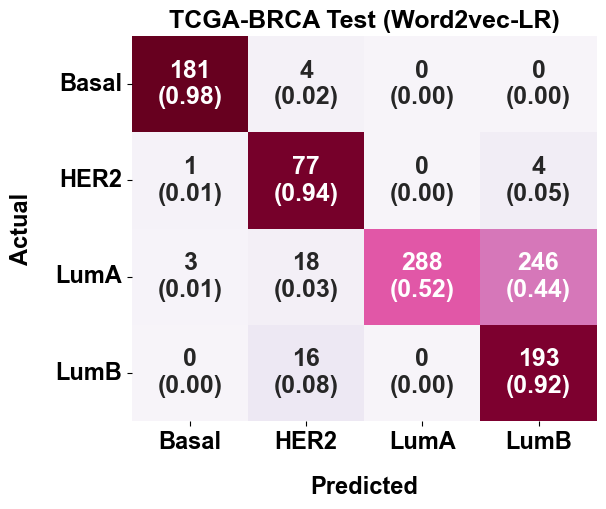

In [22]:
# Compute actual and normalized confusion matrices
cm_actual = metrics.confusion_matrix(y_test.values.ravel(), y_pred_logreg, labels=[0,1,2,3])
cm_normalized = metrics.confusion_matrix(y_test.values.ravel(), y_pred_logreg, labels=[0,1,2,3], normalize='true')

# Define class labels
new_labels = ['Basal', 'HER2', 'LumA', 'LumB']

# Create formatted annotations combining actual counts and normalized values
annotations = np.array([
    [f"{cm_actual[i, j]}\n({cm_normalized[i, j]:.2f})" for j in range(cm_actual.shape[1])]
    for i in range(cm_actual.shape[0])
])

# Convert normalized confusion matrix to DataFrame for visualization
cm_df = pd.DataFrame(cm_normalized, index=new_labels, columns=new_labels)

# Plot heatmap
plt.figure(figsize=(6, 5))
sns.heatmap(cm_df, annot=annotations, fmt='', cmap='PuRd', cbar=False, 
            annot_kws={"size": 18, "family": 'Arial', 'weight':'bold'})

# Formatting labels and title
plt.xticks(fontsize=17, fontfamily='Arial', rotation=0, weight='bold')  
plt.yticks(fontsize=17, fontfamily='Arial', rotation=0, weight='bold') 
plt.xlabel('Predicted', fontsize=17, fontfamily='Arial', labelpad=16, weight='bold')
plt.ylabel('Actual', fontsize=17, fontfamily='Arial', labelpad=16, weight='bold')
plt.title('TCGA-BRCA Test (Word2vec-LR)', fontsize=18, fontfamily='Arial', weight='bold')
plt.show()

#### 3. Merge predicted labels of SVM (best model) with actual labels and survival information

This was created for survival analysis based on model predictions.

In [23]:
# import survival and subtype data of validation set
val_survival_subtype = pd.read_csv("C:/Users/User/Documents/master_thesis_project_analysis/datasets/TCGA_BRCA/tcga_brca_cleaned_data/tcga_brca_survival_subtype.csv",
                                           header=0, index_col=0)

# reorder the index in survival data according to the counts_subtype data
val_survival_subtypee = val_survival_subtype.loc[val_data.index,:]
print('Index of survival data matches with index of gene exp data:', val_survival_subtype.index.equals(val_data.index))

# check whether the subtype column in subtype data is same as subtype column in gene exp data
print('Subtype column of survival data matches with subtype column of gene exp data:',
      val_survival_subtype['subtype'].tolist() == val_data['subtype'].tolist())

Index of survival data matches with index of gene exp data: True
Subtype column of survival data matches with subtype column of gene exp data: True


In [24]:
# define best model
best_model_res = y_pred_svm

# define labels to transform the numeric class labels into subtype names
labels_reverse = {0: 'Basal', 1: 'Her2', 2: 'LumA', 3: 'LumB'}

# convert predicted results of best model into a df
best_model_res_df = pd.DataFrame(best_model_res, index=y_test.index, columns=['predicted_subtype'])
best_model_res_df['predicted_subtype'] = best_model_res_df['predicted_subtype'].replace(labels_reverse)
best_model_res_df['predicted_subtype'].value_counts()

predicted_subtype
LumB     482
LumA     264
Basal    184
Her2     101
Name: count, dtype: int64

In [25]:
# merge survival data, actual labels and predicted labels
best_model_res_survival = val_survival_subtype.join(best_model_res_df)

# get the count of misclassifications
print('Number of misclassifications:', best_model_res_survival.loc[best_model_res_survival['subtype'] 
      != best_model_res_survival['predicted_subtype'],:].shape)

Number of misclassifications: (307, 7)


In [26]:
# check overall survival events
print("Survival event proportion:")
print(best_model_res_survival['vital_status'].value_counts())

# check overall survival events as per actual labels
print("\nSurvival event proportion based on actual subtype labels:")
# check survival events with actual labels
print(best_model_res_survival.loc[best_model_res_survival['subtype'] == 'LumA', 'vital_status'].value_counts())
print(best_model_res_survival.loc[best_model_res_survival['subtype'] == 'LumB', 'vital_status'].value_counts())
print(best_model_res_survival.loc[best_model_res_survival['subtype'] == 'Her2', 'vital_status'].value_counts())
print(best_model_res_survival.loc[best_model_res_survival['subtype'] == 'Basal', 'vital_status'].value_counts())

# check overall survival events as per predicted labels
print("\nSurvival event proportion based on predicted subtype labels:")
# check survival events with actual labels
print(best_model_res_survival.loc[best_model_res_survival['predicted_subtype'] == 'LumA', 'vital_status'].value_counts())
print(best_model_res_survival.loc[best_model_res_survival['predicted_subtype'] == 'LumB', 'vital_status'].value_counts())
print(best_model_res_survival.loc[best_model_res_survival['predicted_subtype'] == 'Her2', 'vital_status'].value_counts())
print(best_model_res_survival.loc[best_model_res_survival['predicted_subtype'] == 'Basal', 'vital_status'].value_counts())

Survival event proportion:
vital_status
Alive    888
Dead     143
Name: count, dtype: int64

Survival event proportion based on actual subtype labels:
vital_status
Alive    488
Dead      67
Name: count, dtype: int64
vital_status
Alive    176
Dead      33
Name: count, dtype: int64
vital_status
Alive    65
Dead     17
Name: count, dtype: int64
vital_status
Alive    159
Dead      26
Name: count, dtype: int64

Survival event proportion based on predicted subtype labels:
vital_status
Alive    236
Dead      28
Name: count, dtype: int64
vital_status
Alive    411
Dead      71
Name: count, dtype: int64
vital_status
Alive    83
Dead     18
Name: count, dtype: int64
vital_status
Alive    158
Dead      26
Name: count, dtype: int64


In [27]:
# create actual_pred column (eg: LumA_LumB)
best_model_res_survival['actual_pred'] = best_model_res_survival['subtype']
for i in range(best_model_res_survival.shape[0]):
    actual_subtype =  best_model_res_survival.loc[best_model_res_survival.index[i], 'subtype']
    pred_subtype =  best_model_res_survival.loc[best_model_res_survival.index[i], 'predicted_subtype']
    best_model_res_survival.loc[best_model_res_survival.index[i], 'actual_pred'] = f"{actual_subtype}__{pred_subtype}"

best_model_res_survival.head(4)

,vital_status,days_to_last_follow_up,days_to_death,overall_survival_days,overall_survival_years,subtype,predicted_subtype,actual_pred
TCGA-D8-A146-01A-31R-A115-07,Alive,643.0,NaN,643.0,1.760,LumA,LumA,LumA__LumA
TCGA-AQ-A0Y5-01A-11R-A14M-07,Dead,NaN,172.0,172.0,0.471,LumA,Her2,LumA__Her2
TCGA-C8-A274-01A-11R-A16F-07,Alive,508.0,NaN,508.0,1.391,LumB,LumB,LumB__LumB
TCGA-BH-A0BD-01A-11R-A034-07,Alive,554.0,NaN,554.0,1.517,LumB,LumB,LumB__LumB


In [28]:
# # save predicted + actual labels + survival data
# best_model_res_survival.to_csv('tcga_brca_word2vec_svm_predictions.csv')